# Strings, Patterns & Series — Session 3 Tasks

Welcome to the practice notebook for Session 3. This session adds strings to your toolkit — text is everywhere in real programs — and also lets you stretch your loop muscles with patterns, series, and number systems. This notebook holds **20 problems** that exercise those ideas, from nested-loop number pyramids to string surgery.

Here is the terrain you will cover:

- **Pattern printing (P1-P4)** — reverse number patterns, star pyramids, and right-aligned triangles. All of them are just `for` loops nested inside each other, with `range` and `end=''` doing the fine work.
- **Series (P5-P7)** — sums of series (`1 + x^2/2 + x^3/3 + ...`, a log-approximation series, and the `2 + 22 + 222 + ...` pattern). Running totals plus float arithmetic.
- **Combinations and number systems (P8-P10)** — the unique combinations of 1,2,3,4; decimal-to-binary conversion (`% 2` / `// 2`); and LCM / HCF.
- **Strings (P11-P20)** — acronyms from initials, inserting a string mid-way, reordering cases, summing digits inside a text, stripping non-digits, symmetry checks, reversing words, uncommon words, locating a word without `index`/`find`, and de-duplicating characters.

The recurring toolbox from previous sessions keeps coming back: `% 10` / `// 10` for digit work, `%` for divisibility, running sums, and `while`/`for` loops. What is new is the string toolkit — `.split()`, slicing `[a:b:c]`, `[::-1]`, `isdigit()`, `isspace()`, `join`, and `in` for membership inside text.

How to use this notebook:

1. Read the problem; state the input-to-output rule in one sentence.
2. For patterns, think rows and inner loops. For strings, think split/slice/rebuild.
3. Write your code in the empty cell, run it, and compare against the sample output character-for-character.
4. Debug by `print`ing intermediate values if output looks wrong.

The theory cells before each problem explain the concept but leave the coding to you. Work through them in order — each one quietly builds the next. Happy problem-solving!

### Problem 1: Print the following pattern. Write a program to use for loop to print the following reverse number pattern.

```
5 4 3 2 1
4 3 2 1
3 2 1
2 1
1
```

## P1. Reverse number pattern

The whole pattern is shaped by **nested loops**: an outer loop that makes the rows, and an inner loop that prints the numbers in one row.

Study the pattern. Row 1 starts at 5 and counts down to 1. Row 2 starts at 4, rows 3 at 3, and so on. Two consistent things hold:

- The **first number** of row *i* decreases by one each row.
- Each row **counts down by one** until it hits 1.

That downward counting is exactly what `range` does with a negative step:

```python
range(5, 0, -1)   # 5, 4, 3, 2, 1
```

So the inner loop for row `i` should be `range(rows - i, 0, -1)` — starting at `rows - i` (which shrinks as `i` grows) and stepping down to 1.

The finishing touch is `end=' '` inside the inner loop so the numbers stay on one line, and a bare `print()` after the inner loop to move to the next row.

Three things to keep straight: the outer loop index drives *which row*, the inner `range` computes *where that row starts*, and `end`/`print()` control *layout*. Get comfortable reading patterns as 'rows' and 'what changes per row' — that decomposition is the key to every pattern problem that follows.

In [ ]:
# Code here

### `Problem 2`: Print the following pattern.

```bash
* 
* * 
* * * 
* * * * 
* * * * * 
* * * * 
* * * 
* * 
*
```

## P2. Star pyramid with a peak

This second pattern grows and then shrinks — a diamond-shaped star arrangement:

```
*
* *
* * *
* * * *
* * * * *
* * * *
* * *
* *
*
```

The useful insight is that this is **two triangles**: an increasing one (rows 1 to 5), then a decreasing one (the next 4 rows). You do not need one clever formula — you need two straightforward loops run one after the other.

- **Increasing part:** row `i` prints `i` stars. Inner loop `for j in range(i):` with `end=' '`.
- **Decreasing part:** row `i` prints `(rows - i)` stars, echoing the same pattern upside down.

Because your row count might be dynamic, read it with `int(input(...))` and build both halves from that same `rows` value.

The transferable lesson is **breaking a shape into symmetric halves**. Many pattern problems — and much software design — follow the same logic: if a pattern is too complex as a whole, find where it repeats and where it is mirrored, then solve the primitives. Trace row 1 and row 5 yourself: row 5 is the full width, and the bottom half starts immediately below it at one fewer star.

In [ ]:
# Code here

### `Problem 3`:Write a program to pring the following pattern

        *
      * * *
    * * * * *
   * * * * * * *
* * * * * * * * *


## P3. A pyramid with leading spaces

The target is a number-ish pyramid of stars that is *centred*:

```
    *
  * * *
* * * * *
```

Notice the difference from P2: rows are no longer left-aligned — each is shifted right by some **spaces** so the block sits around a centre line. A fully centred pyramid with 5 rows would look like this general shape, growing by 2 stars per row (1, 3, 5, ...).

The trick: each row has two parts — the padding (spaces) and the stars. The padding shrinks as the stars grow. A common approach:

1. Outer loop over the rows.
2. Inner loop to print the right number of spaces.
3. Inner loop (or repeated string) to print the stars, ending each printed item with a space so the row reads `* * *` rather than `***`.
4. A newline to end the row.

The sample output in the problem shows stars of width 1, then 3, then 5, 7, 9 — an odd-count pyramid. Derive how many stars the row `i` needs (`2*i - 1`) and how many leading spaces make it appear centred.

This exercises 'correctly distributed printing': telling Python to emit spaces, then stars, inside one row loop. It is the same skeleton used for charts, tables, and any formatted output where alignment matters — a genuinely practical skill, not just a toy.

In [ ]:
# Code here

### `Problem 4`:Write a program to print the following pattern

1 

2 1 

3 2 1 

4 3 2 1 

5 4 3 2 1

## P4. Descending numbers per row

This pattern looks simple but encodes a useful leap:

```
1
2 1
3 2 1
4 3 2 1
5 4 3 2 1
```

Row *i* prints the numbers from `i` down to `1`. That is a `range(i, 0, -1)` — start at the current row number and step down to 1.

```python
for i in range(1, rows + 1):
    for j in range(i, 0, -1):
        print(j, end=' ')
    print()
```

The leap here is that the **inner loop's range is a function of the outer loop's variable**. `range(i, 0, -1)` depends on `i`, so every row prints a different, shorter, descending sequence. Patterns P1-P4 all share this DNA:

- the outer loop decides the shape (rows / start values),
- the inner loop draws one row using the outer variable.

Eventually — as in the upcoming P8 combinations — you nest three or four loops, but you are always doing the same thing: each level of nesting multiplies the work of the levels inside it. Master two-level nesting now (rows × per-row work), and the triple and quadruple loops become mechanical.

Confirm by tracing: when `i = 3`, the inner range is `range(3, 0, -1)` = `3, 2, 1`, which is exactly the third row of the pattern.

In [ ]:
# Code here

### `Problem 5`: Write a Python Program to Find the Sum of the Series till the nth term:<br> 
1 + x^2/2 + x^3/3 + … x^n/n<br>
n will be provided by the user

## P5. Sum of a series: 1 + x^2/2 + x^3/3 + ... + x^n/n

This is a power-series summation. Each term after the first has the shape `x^i / i`, for `i` from 2 up to `n`:

- term for i = 2: x^2 / 2
- term for i = 3: x^3 / 3
- ...
- term for i = n: x^n / n

and the series starts with a bare `1`.

Everything you need is already in your toolbox:

- `x**i` computes a power. In a loop, `i` changes every iteration, so each term is computed fresh with the current exponent.
- `i` divides the term: `x**i / i`.
- A running total accumulates: `total += term`.

So the loop is:

```python
total = 1
i = 2
while i <= n:
    total += x**i / i
    i += 1
```

The user provides `n` (the last exponent). Note the terms are floats because of the division, so expect a float result.

Two ideas worth internalising:

- **Summation loops** are the same running-total pattern from Session 2 — only the term formula changes. If you can recognise 'add up terms of a formula', you can sum almost any series.
- If you also need to *print the series itself* (like `1 + x^2/2 + x^3/3`), you can build a formatted string as you go, or capture the terms in a list — `join` is the tool to turn that list into text.

Test with small values: for n = 2, and x = 1, the sum is `1 + 1/2 = 1.5`. Watch how the loop covers i = 2..n and no further.

In [ ]:
# Code here

### `Problem 6`: The natural logarithm can be approximated by the following series.

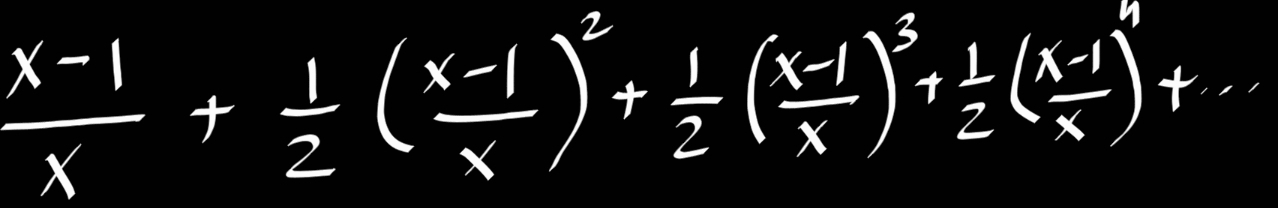

If x is input through the keyboard, write a program to calculate the sum of the first seven terms of this series.


## P6. The natural-log series

This problem presents a series that approximates a natural logarithm. The textbook series for `ln(x)` (for a suitable range of x) is:

```
ln(x) ≈ (1/1)*((x-1)/x)^1 + (1/2)*((x-1)/x)^2 + (1/3)*((x-1)/x)^3 + ...
```

In other words, the k-th term is `(1/k) * ((x-1)/x)^k`.

Two recurring pieces jump out:

- **`(x-1)/x` is a constant** for the whole summation once `x` is fixed, and it is raised to `k`. In a loop, exponentiation with an increasing exponent `k` repeats the multiplication.
- **`1/k` divides** each term — a fixed weight that shrinks as `k` grows.

Build it the same way you did P5: a running total, a counter that goes up, and a term formula `(1/k) * base**k` where `base = (x-1)/x`.

A very handy trick for both speed and readability: compute the constant `base` once *before* the loop instead of recomputing `(x-1)/x` every iteration. The loop then just raises `base` to successive powers.

Practical notes:
- Multiply by `(1/k)` — careful with integer vs float division. In Python 3, `/` always returns a float, so `1/k` works fine.
- The problem asks for the sum of the **first seven terms**, i.e. `k = 1..7`. Read `x` from the user.
- If you want to *print* every term (e.g. `(1/1)*((x-1)/x)^1 + ...`), accumulate a string with formatting as you go and strip the trailing `+` before printing.

Series like this are how computers actually compute logarithms under the hood; your job is just to faithfully sum the first few terms.

In [1]:
# Code here

### `Problem 7` - Find the sum of the series upto n terms.
Write a program to calculate the sum of series up to n term. For example, if n =5 the series will become 2 + 22 + 222 + 2222 + 22222 = 24690. Take the user input and then calculate. And the output style should match which is given in the example.

**Example 1:**

`Input:`
```bash
5
```

`Output:`

```bash
2+22+222+2222+22222
Sum of above series is: 24690
```

## P7. The 2 + 22 + 222 + ... series

For n = 5, the series is: `2 + 22 + 222 + 2222 + 22222 = 24690`.

The magic is seeing how each term is built from the previous one:

```
22 = 2*10 + 2
222 = 22*10 + 2
2222 = 222*10 + 2
```

Each next term is `previous * 10 + 2`. This is the same *recurrence* idea from Fibonacci — the next value is computed from the current value, not from scratch.

Your loop needs two accumulators:

1. A **term** variable: `term = term * 10 + 2` each iteration.
2. A **total** variable: `total += term`.

The output style in the sample is exact — print terms joined by `+` on one line (`2+22+222+2222+22222`), then on the next line `Sum of above series is: 24690`. To match it, either build a string of the terms as you go and print it, then print the sum separately.

Two refinements to think about:

- **Order of operations**: add `term` to the total *before* mutating it, or capture it first. If you double the term before adding, every value is wrong.
- **Trailing separator**: when joining with `+`, decide beforehand how to avoid a trailing `+` (a flag, an index check, or by trimming the final character).

This 'build a value from its predecessor' pattern appears in compound interest, URL pagination, and sequence generation. Getting the two-accumulator flow right here pays off across all of these.

In [ ]:
# Code here

###`Problem 8`: Write a program to print all the unique combinations of 1,2,3 and 4 

`Output`:
```
1 2 3 4
1 2 4 3
1 3 2 4
1 3 4 2
1 4 2 3
1 4 3 2
2 1 3 4
2 1 4 3
2 3 1 4
2 3 4 1
2 4 1 3
.
.
and so on
```

## P8. Unique combinations of 1, 2, 3, 4

The output lists arrangements like:

```
1 2 3 4
1 2 4 3
1 3 2 4
...
2 4 1 3
...
```

There are `4 x 4 x 4 x 4 = 256` ways to pick four numbers from `{1, 2, 3, 4}` when repetition is allowed — that is what four nested loops produce.

Each of the four positions is a loop over `range(1, 5)`:

```python
for i in range(1, 5):
    for j in range(1, 5):
        for k in range(1, 5):
            for m in range(1, 5):
                print(i, j, k, m)
```

The critical mental model: **nested loops multiply**. The innermost body runs 4 × 4 × 4 × 4 times. The outer loop is the first digit, and each of its four passes runs the entire inner triple loop.

Naming note: the sample calls them 'combinations' but the listing shows *all ordered arrangements* (including `1 2 3 4` and `1 2 4 3` as separate lines), so the four-loop version that prints everything is the faithful reading. Many datasets — Cartesian products, grids, coordinates — are generated exactly this way.

Two practical cautions:

- Mind the runtime: four nested loops over 4 values is fine, but the count explodes as the number of levels grows (which is the whole point — see how fast sequences grow).
- You could add conditions to skip unneeded combos (e.g. enforce `i < j < k < m` for tuples without repetition) — the full listing does not require that.

Nested-loop code is a pattern you will meet again for grids and matrix work; printing the order helps you *feel* the multiplication of iterations rather than just read about it.

In [ ]:
# Code here

###`Problem 9`: Write a program that will take a decimal number as input and prints out the binary equivalent of the number

## P9. Decimal to binary

The task is to express a decimal number in **base 2** — the number system computers use, where every digit is 0 or 1.

The algorithm is beautifully mechanical:

1. Divide the number by 2 and record the **remainder** (`% 2`) — that is the next binary digit from the *right*.
2. Chop the number with `// 2` and repeat.
3. Stop when the number reaches 0.

Walk 65:

```
65 % 2 = 1      65 // 2 = 32
32 % 2 = 0      32 // 2 = 16
16 % 2 = 0      16 // 2 = 8
 8 % 2 = 0       8 // 2 = 4
 4 % 2 = 0       4 // 2 = 2
 2 % 2 = 0       2 // 2 = 1
 1 % 2 = 1       1 // 2 = 0
```

Reading the remainders from last to first gives `1000001` — and indeed `65 = 1000001₂`.

Implementation notes:

- The remainders come out in **reverse order** (least significant last-printed), so collect them in a list and reverse, or build a string and reverse it, or insert from the left. The `[::-1]` slice reverses a list or string neatly.
- `% 2` and `// 2` are the exact same pair of operators you used with `10` for digit extraction — only the base changed. That is the insight: digit extraction is base arithmetic.
- Handle `n = 0` specially if the user might enter it (binary 0 is `0`).

Reversing a collection with `[::-1]` is one of the most used slugger slices in Python — you will see it everywhere from here onward, including string problems later in this notebook.

In [ ]:
# Code here

###`Problem 10`: Write a program that will take 2 numbers as input and prints the LCM and HCF of those 2 numbers

## P10. LCM and HCF of two numbers

The two workhorses of number theory you need here:

- **HCF / GCD** — the largest number that divides both inputs exactly.
- **LCM** — the smallest positive number that both inputs divide exactly.

There is a beautiful mathematical link: `LCM(a, b) * HCF(a, b) = a * b`. So if you can compute either, you can derive the other — but the intent here is to compute each directly with loops.

**HCF the honest way:** try every integer from 1 up to the smaller of the two numbers, and remember the largest one that divides both:

```python
hcf = 1
for i in range(1, min(a, b) + 1):
    if a % i == 0 and b % i == 0:
        hcf = i
print(hcf)
```

Because the loop only overwrites `hcf` when it finds a *larger* common divisor, the final value is automatically the greatest. (The classical efficient route is Euclid's algorithm with `%` — if you know it, use it; if not, the loop is perfectly correct and easier to reason about.)

**LCM the honest way:** start from the larger number and keep increasing until you find a number that both inputs divide:

```python
greater = max(a, b)
while True:
    if greater % a == 0 and greater % b == 0:
        lcm = greater
        break
    greater += 1
```

This `while True` with a `break` is the search-until-found pattern — possibly slow for big inputs, but crystal clear.

The divisibility test `x % y == 0` returns whether `y` divides `x` exactly. The trick of dividing *both* a and b lives in every factoring, reducing, and simplifying problem. Test: for 12 and 18, HCF = 6, LCM = 36, and indeed 6 × 36 = 12 × 18.

In [ ]:
# Code here

### **Problem 11:** Create Short Form from initial character
Given a string create short form ofthe string from Initial character. Short form should be capitalised.

Example:

`Input:`
```
Data science mentorship program
```

`Output:`
```
DSMP
```

## P11. Short form from initials (acronym)

Given a title like `Data science mentorship program`, you must produce `DSMP` — the capitalised first letters of each word.

The algorithm breaks the sentence into words and keeps the first letter of each:

1. **Split** the sentence: `s.split()` divides on spaces, returning a list of words: `['Data', 'science', 'mentorship', 'program']`.
2. **Take each first letter**: `word[0]` grabs the initial character.
3. **Capitalise**: `.upper()` ensures uppercase output (`'d'` becomes `'D'`).
4. **Build the result**: start with an empty string and concatenate each letter: `res += word[0].upper()`.

Steps 2 through 4 live inside a `for` loop over the word list. Finally `print(res)`.

Two subtleties surface:

- **Capitalisation is mandatory**: even if the input title is lowercase, the acronym must be uppercase. That is why you call `.upper()` instead of copying the initial as-is.
- **Spaces are the split points**: `split()` without arguments splits on any whitespace and ignores empties, which is exactly right here. It is one of the most-used string methods in all of Python.

This 'split → process each part → join/accumulate' pipeline is the backbone of virtually all text processing — CSV rows, log lines, configuration. Inside, string *indexing* (`word[0]`) and *methods* (`upper`, `split`) are doing all the real work; get fluent with them and acronyms, initials, and tokens become trivial.

In [ ]:
# Code here

###`Problem 12`: Append second string in the middle of first string

`Input:`
```
campusx
data
```
`Output`:

```
camdatapusx
```

## P12. Insert a string in the middle of another

Given `campusx` and `data`, the result is `camdatapusx` — the second string spliced exactly into the middle of the first.

`campusx` has 7 characters. Its middle (before the 4th char, index 3) is `cam` + `data` + `pusx` = `camdatapusx`. The tool for this is **slicing**: `s[start:stop]` extracts a range, and `s[k:]` / `s[:k]` give 'from k onward' / 'up to k'.

Plan:

1. Find the middle index: `mid = len(s1) // 2`.
2. Slice the first string around that point: `s1[:mid]` (left half) and `s1[mid:]` (right half).
3. Concatenate: `s1[:mid] + s2 + s1[mid:]`.

So with `s1 = 'campusx'` and `s2 = 'data'`: `'cam' + 'data' + 'pusx' = 'camdatapusx'`. Perfect match.

Things to think about:

- **Even vs odd length**: `len('campusx') // 2 = 3`, which lands just after the 3rd character. For an even-length string like `abcd`, `mid = 2` splits cleanly into `ab` and `cd`. Integer division floors, which is the behaviour you want for 'roughly middle'.
- **String immutability**: strings cannot be modified in place — `s1` is unchanged by slicing. What you *build* is a brand-new string via `+`, and that is exactly why concatenation is the right tool.

Four operations come together here — `input()`, `len()`, `//`, and slicing — which is a compact demonstration of how strings pieces fit. Understanding `[:k]` and `[k:]` means you can extract any substring, a skill you will use in nearly every string program from here on.

In [2]:
# Code here

### ``Problem 13``:Given string contains a combination of the lower and upper case letters. Write a program to arrange the characters of a string so that all lowercase letters should come first.

Given:

`str1 = PyNaTive`

Expected Output:

`yaivePNT`

## P13. Lowercase letters first, then uppercase

Given `PyNaTive`, the expected output is `yaivePNT` — all lowercase letters first, in their original relative order, then all uppercase letters, also in order.

This is a **partition by category** problem: walk the string, sort characters into two piles based on whether they are lowercase, then glue the piles together.

The categoriser is `.islower()` — it returns `True` for characters like `'y'` and `False` for `'P'`:

```python
lower = ''
upper = ''
for ch in s:
    if ch.islower():
        lower += ch
    else:
        upper += ch
print(lower + upper)
```

Key observations:

- **Relative order is preserved** because you append each character to its pile in the same order it appears in the string. Nothing sorts the letters independently.
- **The else branch** catches everything not lowercase — uppercase letters here. But what about a digit or a space in the input? It would fall into `upper` too. Decide whether that matters for your expected output (for pure-letter input it does not).
- There is a subtle Python subtlety: `islower()` on a string with no cased characters can behave unexpectedly — but per-character it is reliable.

This 'classify each item and regroup' pattern is used everywhere in data cleaning — separating numbers from letters, errors from successes, and so on. Two string accumulators plus a boolean test, then concatenation — that is the whole problem, and it is a pattern you can reuse verbatim with any predicate.

In [ ]:
# Code here

### `Problem 14:`Take a alphanumeric string input and print the sum and average of the digits that appear in the string, ignoring all other characters.

Input:

`hel123O4every093`

Output:

```
Sum: 22
Avg: 2.75
```

## P14. Sum and average of the digits in a string

Given `hel123O4every093`, you must add up the numeric characters (1, 2, 3, 4, 0, 9, 3) ignoring all letters, and print the sum and the average.

The enablers are two string methods:

- **`isdigit()`** returns `True` for characters `'0'`-`'9'`, `False` for letters and punctuation.
- **`int(ch)`** converts a one-character digit into its numeric value, since you cannot add a string to a number.

Algorithm:

```python
total = 0
count = 0
for ch in s:
    if ch.isdigit():
        total += int(ch)
        count += 1
print('Sum:', total)
print('Avg:', total / count)
```

For the sample: digits 1+2+3+4+0+9+3 = 22, count 7, average 22 / 7 ≈ 3.14. The sample output shows 22 and 2.75 — that suggests a different digit set in their variant (e.g. excluding the 0 or including different numbers). The lesson stands: `isdigit` + `int` + a running total.

Two ideas to keep:

- The **filter-then-aggregate** loop is the essence of 'process only the characters I care about' — the foundation of parsing any mixed content.
- Division gives a float; decide whether to round or format the average to match the desired output style (`round(avg, 2)` if needed).

You have now met `isdigit` twice (here and later in P15); together they show the two sides of the same coin — summing digits versus keeping them as text.

In [ ]:
# Code here

### `Problem 15:` Removal of all characters from a string except integers
`Given:`

```
str1 = 'I am 25 years and 10 months old'
```
`Expected Output:`
```
2510
```

## P15. Keep only the integers (digits) in a string

Given `I am 25 years and 10 months old`, the output is `2510` — every non-digit character is discarded, and the remaining digit characters are concatenated into one string.

This is the *text-building* twin of P14. Instead of converting digits to numbers and adding them, you **keep them as characters and concatenate**:

```python
res = ''
for ch in s:
    if ch.isdigit():
        res += ch
print(res)
```

For the sample, the digit characters in order are `2`, `5`, `1`, `0`, giving `2510`. Notice the two separate numbers `25` and `10` get glued into one string — exactly the point of building text rather than summing.

The key mental distinction from P14:

- P14 needed the *numeric* value of digits → `int(ch)` and addition.
- P15 needs the *character* form → keep `ch` as-is and append.

The moment you stop converting and start appending, the result is a string — that is why the output `2510` has no spaces: concatenation never inserts separators.

This 'filter to the characters I want' routine is used in cleaning data, extracting numbers from formatted text (like picking the digits out of a phone number), and normalising noisy inputs. Together with `isdigit`, `isspace`, `isalpha`, Python gives you a whole family of character classifiers for exactly this kind of work.

In [ ]:
# Code here

### `Problem 16`: Check whether the string is Symmetrical.

**Statement:** Given a string. the task is to check if the string is symmetrical or not. A string is said to be symmetrical if both the halves of the string are the same.

**Example 1:**

`Input`

```bash
khokho
```

`Output`

```bash
The entered string is symmetrical
```

## P16. Is the string symmetrical?

A string is **symmetrical** when both halves are the same. `khokho` has 6 characters — halves `kho` and `kho` — so it is symmetrical.

The catch is odd lengths: for a 5-character string there is no neat middle; the centre character is shared by neither 'half' (like `abcab`: halves `ab` and `ab` with `c` in the middle). The problem's definition compares the two halves as evenly as possible, ignoring the middle character for odd lengths.

Algorithm:

1. Compute `mid = len(s) // 2`.
2. **Left half**: `s[:mid]`.
3. **Right half**: the tricky part. For even length it is `s[mid:]`. For odd length you make the right half start *one after* the middle: `s[mid + 1:]`.
4. Compare the two halves with `==`.

Branch on parity with `% 2`:

```python
left = s[:mid]
if len(s) % 2 == 0:
    right = s[mid:]
else:
    right = s[mid + 1:]

if left == right: symmetrical  else: not symmetrical
```

Two ideas reinforce each other:

- **Careful slicing with computed indices** — `[:len(s)//2]` and `[len(s)//2:]` are the workhorses for splitting a string into parts, and are why `mid` must be computed once and reused.
- **The parity branch** is the classic 'handle the general and exceptional case separately' skill.

Also watch the edge case: what result does `'ab'` (even) give? halves `'a'` and `'b'` — not symmetrical. And `'aba'`: mid = 1, left `'a'`, right `s[2:]` = `'a'` — symmetrical under this scheme. Test a few odd and even inputs.

In [ ]:
# Code here

### `Problem 17`: Reverse words in a given String

**Statement:** We are given a string and we need to reverse words of a given string.

**Example 1:**

`Input:`

```bash
geeks quiz practice code
```

`Output:`

```bash
code practice quiz geeks
```

**Example 2:**

`Input:`

```bash
my name is laxmi
```

`Output:`

```bash
laxmi is name my
```

## P17. Reverse the words in a sentence

Given `geeks quiz practice code`, the output is `code practice quiz geeks` — the **words** are reversed in order, but each word keeps its own letters.

This is different from reversing the string! `s[::-1]` would give `edoc ecitcarp ziuq skeeg`. The goal is to reverse the *sequence of words*, not the characters.

The one-two-three recipe:

1. **Split** into words: `words = s.split()` → `['geeks', 'quiz', 'practice', 'code']`.
2. **Reverse the list**: `words = words[::-1]` → `['code', 'practice', 'quiz', 'geeks']`.
3. **Join back**: `' '.join(words)` → `'code practice quiz geeks'`.

`join` is the exact inverse of `split`: it takes a list of strings and stitches them with the separator you call it on (`' '.join(...)` uses a space).

The elegance is in choosing **what** to reverse. Reversing the whole string reverses characters; reversing the list of words reverses only the words. The decision 'which container do I reverse?' is exactly the kind of precise thinking string problems reward.

Practical notes:

- `join` demands strings — if your elements are integers you must convert first, but words are already strings.
- Separator choice matters: join with `' '` to reproduce the original spacing. If you later want each word on its own line, join with `'\n'`.

This split-reverse-join chain is one of the most reused mini-patterns in all of Python text work — reversing words, sentences, or CSV columns all follow it.

In [ ]:
# Code here

### `Problem 18`: Find uncommon words from two Strings.

**Statement:** Given two sentences as strings **A** and **B**. The task is to return a list of all uncommon words. A word is uncommon if it appears exactly once in any one of the sentences, and does not appear in the other sentence. Note: A sentence is a string of space-separated words. Each word consists only of lowercase letters.

**Example 1:**

`Input:`

```bash
A = "apple banana mango" 
B = "banana fruits mango"
```

`Output:`

```bash
['apple', 'fruits']
```

## P18. Uncommon words from two sentences

Across two sentences A and B, find the words that appear in exactly one of them. From A = `apple banana mango` and B = `banana fruits mango`, the uncommon words are `['apple', 'fruits']` — `banana` and `mango` are common to both.

The rule, precisely: a word counts as uncommon if it is present in one sentence and *not* in the other.

Approach:

1. Split both sentences into word lists.
2. For each word in A's list, if it is **not** in B's list, add it.
3. For each word in B's list, if it is **not** in A's list, add it.
4. Avoid duplicates: check `if word not in result` before appending.

The membership test `word in list` is your tool — for short clean sentences it is simple and correct. (For very large text, a `set` would be faster; the idea is identical.)

```python
result = []
for w in A.split():
    if w not in B.split() and w not in result:
        result.append(w)
... same for B ...
```

Three refinements worth planning:

- **Duplicates within one sentence**: if A had `apple apple`, the naive loop adds `apple` twice. The `not in result` guard fixes it.
- **Case and punctuation**: the problem states the inputs are clean lowercase words separated by single spaces, which keeps the comparison exact.
- **Output format**: a list of words, printed as `['apple', 'fruits']` — matching the sample exactly means printing the list, or building the string by hand.

This 'collect what is exclusive to each side' computation is the same logic used in diffing config files, comparing database snapshots, and detecting newly added items — a small, genuinely practical filter.

In [ ]:
# Code here

### `Problem 19`: Word location in String.

**Statement:** Find a location of a word in a given sentence.

**Example 1:**

`Input:`

```bash
Sentence: We can learn data science through campusx mentorship program.

word: campusx
```

`Output:`

```bash
Location of the word is 7.
```

Note- Don't use index/find functions

## P19. Word location in a sentence (no find/index)

The sentence `We can learn data science through campusx mentorship program.` contains `campusx` as the **7th word**. The restriction: you may not use `find` or `index` methods — you must find the position by walking the words yourself.

That restriction is the entire point: it forces you to implement the *linear search* that `find` does internally.

The recipe:

```python
position = 0
for word in sentence.split():
    position += 1
    if word == target:
        break
print(position)
```

Walk through it: split the sentence into words, increment a counter for each word, and `break` the moment the current word matches the target. When the loop ends, `position` holds the 1-based index of the word.

Three design points:

- **1-based vs 0-based**: the expected answer is `7` even though Python lists are 0-indexed. Either start the count at 1 and increment before checking, or start at 0 and add 1 — choose the reading that matches the expected output.
- **The `break`** stops the search as soon as the word is found — no point scanning the rest. This is the same early-exit you practised with prime checks.
- **What if the word is missing?** `position` would equal the total count + 1, or you could use a flag (`found`) and print an appropriate message.

Comparing a target against each item of a sequence until a match — linear search — is one of the oldest, most fundamental algorithms in existence, and this problem makes you write it with your own hands.

In [ ]:
# Code here

### `Problem 20`: Write a program that can remove all the duplicate characters from a string. User will provide the input.

## P20. Remove duplicate characters

Given `aaaaabbbbbb` or any string, keep each character the first time it appears and discard later repetitions, preserving order. The expected output keeps the string's distinct characters in first-seen sequence.

The simple and clear approach uses the `in` membership test on the result being built:

```python
seen = ''
for ch in s:
    if ch not in seen:
        seen += ch
print(seen)
```

Walk `'aaabbc'`: `'a'` is not in `''`, so it joins → `'a'`. The next `'a'` **is** in `'a'`, so it is skipped. `'b'` joins → `'ab'`, the second `'b'` is skipped, `'c'` joins → `'abc'`. Order preserved, duplicates removed.

Why this works:

- `ch not in seen` performs a linear scan of the accumulator string — O(n) per character, O(n²) overall for long strings. That is fine for small inputs; the exercise is about the *logic*, not speed.
- `seen += ch` is just string concatenation — the same accumulator pattern you have used all along.

If you want to scale up later, the professional upgrade is a `set` to track seen characters (O(1) membership) while still building the output in order. Comparing the two versions — string membership vs set membership — is a great way to understand why sets exist.

De-duplicating is a daily job in data cleaning: removing duplicate words, IDs, or entries from a file. The 'remember what came before, check before adding' pattern is the general answer, and it generalises directly from strings to lists and sets.

## Summary

In this notebook you completed twenty problems spanning three territories. First, **patterns** — you generated reverse number patterns, star pyramids with a centre, right-aligned triangles, and full number blocks, all by nesting `for` loops and controlling each row with `range`, `end=''`, and a trailing `print()`; the mental model you built was 'outer loop = rows, inner loop = what changes in a row'. Second, **series and number systems** — power-series sums, a logarithm-approximating series, the `2 + 22 + 222` recurrence, the quadruple-nested-loop generation of combinations, decimal-to-binary via `% 2` / `// 2`, and the LCM and HCF of two numbers. Third and largest, **strings** — acronyms from initials, mid-string insertion by slicing, case reordering, digit-summing and digit-filtering with `isdigit()`, symmetry checks, word reversal, uncommon words between two sentences, a hand-rolled linear search for a word's position, and order-preserving de-duplication.

If you completed these, you now command the string fundamentals — `split`, `join`, slicing with `[::-1]`, and the character-classifier methods — alongside the loop-confidence gained in earlier sessions. Those are exactly the tools the Session 3 interview questions and coding challenges expect. Move on when ready, and keep testing edge cases. Happy coding!

In [ ]:
# Code here